In [3]:
!pip install --upgrade tensorflow==2.9.0 tensorflow-addons==0.17.0 keras

     |████████████████████████████████| 511.7 MB 3.3 kB/s  eta 0:00:011     |███████████████████████████     | 432.4 MB 115.6 MB/s eta 0:00:01
     |████████████████████████████████| 1.1 MB 38.4 MB/s eta 0:00:01
     |████████████████████████████████| 1.7 MB 56.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 37.2 MB/s eta 0:00:01
     |████████████████████████████████| 2.4 MB 48.9 MB/s eta 0:00:01
     |████████████████████████████████| 133 kB 70.0 MB/s eta 0:00:01
     |████████████████████████████████| 438 kB 56.2 MB/s eta 0:00:01
     |████████████████████████████████| 5.8 MB 53.1 MB/s eta 0:00:01
     |████████████████████████████████| 15.7 MB 43.8 MB/s eta 0:00:01
     |████████████████████████████████| 24.5 MB 44.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.9 MB 47.9 MB/s eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.5
    Uninstalling numpy-1.19.5:
      Successfully uninstalled numpy-1.19.5
  Attempting u

In [4]:
!pip install tensorflow-addons==0.13.0  # Compatible with TF 2.4.0

     |████████████████████████████████| 679 kB 13.6 MB/s eta 0:00:01
  Attempting uninstall: tensorflow-addons
    Found existing installation: tensorflow-addons 0.17.0
    Uninstalling tensorflow-addons-0.17.0:
      Successfully uninstalled tensorflow-addons-0.17.0
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


# Setup

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_addons as tfa
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import StratifiedKFold

import albumentations as A
from tqdm import tqdm

# Prepare the data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter

# Constants
NUM_CLASSES = 6
IMAGE_SIZE = 224
BATCH_SIZE = 32
IMAGE_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)
input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3)

# Paths
DATA_DIR = "/kaggle/input/ecg-images/ECG-IMAGES/ECG_Image_data/train"

In [13]:
# Create dataframe from image directory
image_paths = []
classes = []

for class_name in os.listdir(DATA_DIR):
    class_dir = os.path.join(DATA_DIR, class_name)
    if os.path.isdir(class_dir):
        for img_name in os.listdir(class_dir):
            image_paths.append(os.path.join(class_name, img_name))
            classes.append(class_name)

train_df = pd.DataFrame({
    'Image': image_paths,
    'Class': classes
})

# Verify we have 6 classes
assert len(train_df['Class'].unique()) == NUM_CLASSES

In [14]:
# Stratified split
train_df, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['Class'],
    random_state=42
)

In [15]:
train_transforms = A.Compose([
    A.Rotate(limit=40),
    A.Cutout(num_holes=4, max_h_size=8, max_w_size=8),
    A.ShiftScaleRotate(),
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.RandomGridShuffle()
])

def augment_image(image):
    data = {"image": image}
    aug_data = train_transforms(**data)
    return aug_data["image"]

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=lambda x: augment_image(x)
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATA_DIR,
    x_col="Image",
    y_col="Class",
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=True,
    class_mode="categorical",
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

valid_generator = val_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=DATA_DIR,
    x_col="Image",
    y_col="Class",
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=False,  # Important for validation
    class_mode="categorical",
    target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

Found 22723 validated image filenames belonging to 6 classes.
Found 5681 validated image filenames belonging to 6 classes.


Class mapping: {'F': 0, 'M': 1, 'N': 2, 'Q': 3, 'S': 4, 'V': 5}


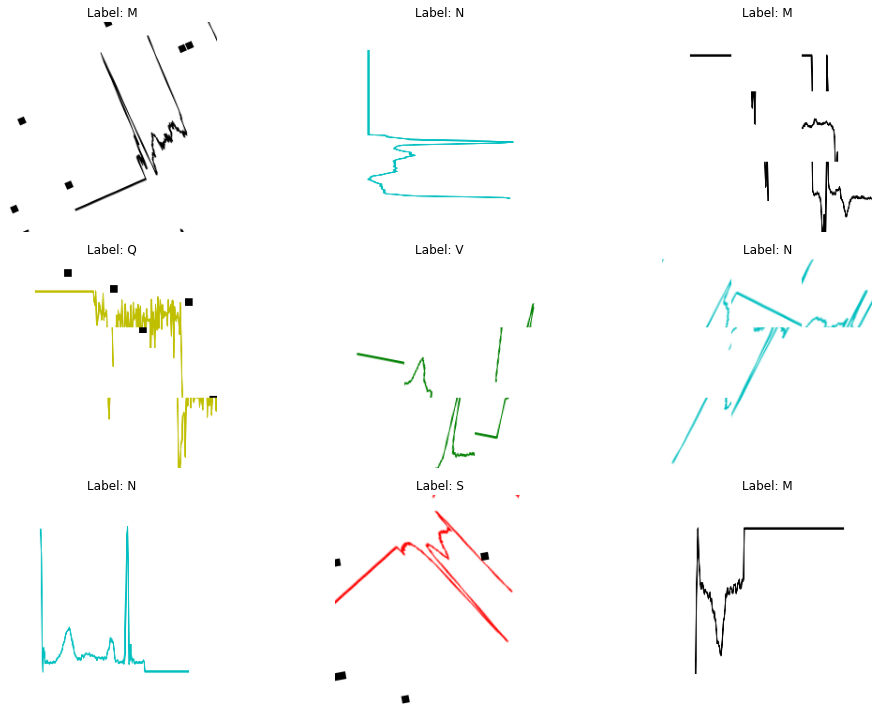

In [17]:
# Get class indices
classes = train_generator.class_indices
class_names = list(classes.keys())
print("Class mapping:", classes)

# Visualization function
def view_images(generator):
    images, labels = next(generator)
    plt.figure(figsize=(15, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i])
        plt.title(f"Label: {class_names[np.argmax(labels[i])]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize training images
view_images(train_generator)

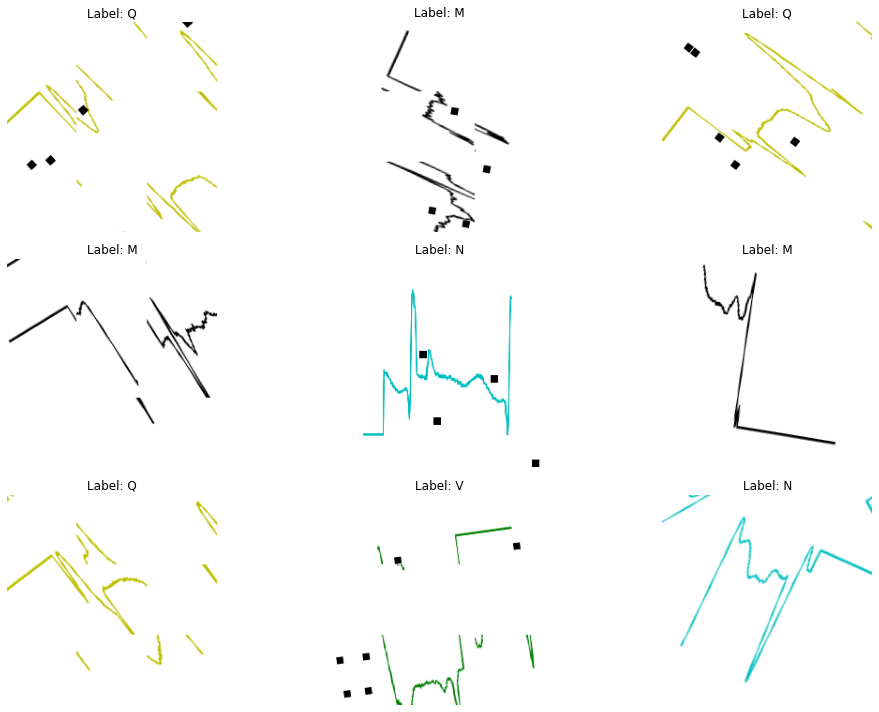

In [18]:
view_images(train_generator)

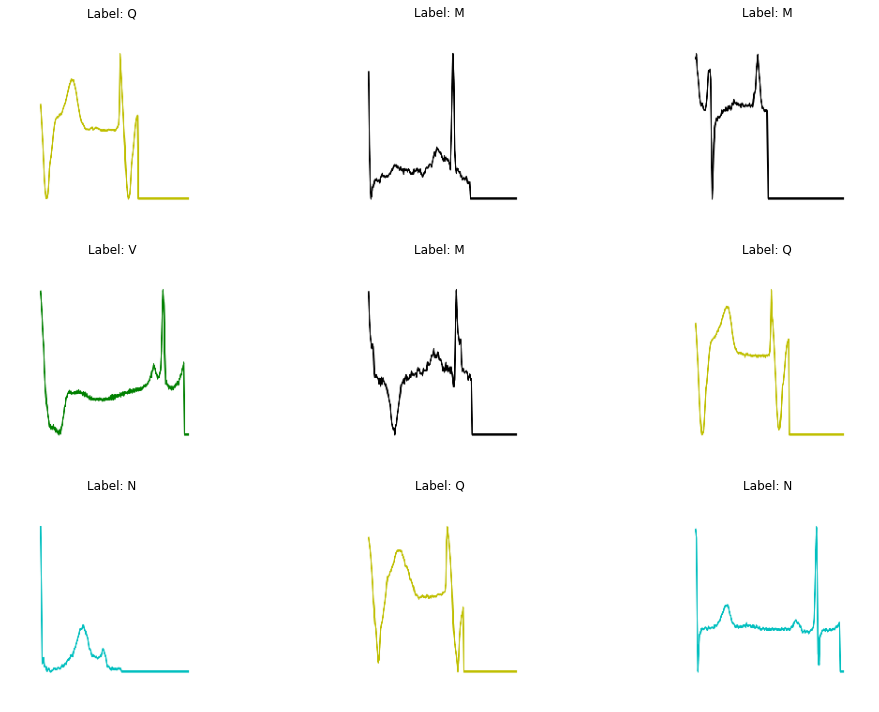

In [19]:
view_images(valid_generator)

In [20]:

counter = Counter(train_generator.classes)                          
max_val = float(max(counter.values()))       
class_weights = {class_id : max_val/num_images for class_id, num_images in counter.items()}                     
class_weights

{4: 3.78177727784027,
 2: 1.7105062325108116,
 3: 1.3068999028182702,
 5: 1.451954221550421,
 1: 1.0,
 0: 13.081712062256809}

# Use data augmentation

In [21]:
data_augmentation = keras.Sequential(
    [
        layers.experimental.preprocessing.Normalization(),
        layers.experimental.preprocessing.Resizing(image_size, image_size),
#         layers.experimental.preprocessing.RandomFlip("horizontal"),
#         layers.experimental.preprocessing.RandomRotation(factor=0.02),
#         layers.experimental.preprocessing.RandomZoom(
#             height_factor=0.2, width_factor=0.2
#         ),
    ],
    name="data_augmentation",
)
# Compute the mean and the variance of the training data for normalization.
# data_augmentation.layers[0].adapt(x_train)

# Implement multilayer perceptron (MLP)

In [22]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# Implement patch creation as a layer

In [23]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super(Patches, self).__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches

# Implement the patch encoding layer

In [24]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patch) + self.position_embedding(positions)
        return encoded


# Build the ViT model

In [25]:
pip install vit-keras

  Created wheel for validators: filename=validators-0.20.0-py3-none-any.whl size=19567 sha256=7a4b87e1ce481ffcdb59ad06b8b3284947587a35c82b7e142aa0a1c389c93048
  Stored in directory: /root/.cache/pip/wheels/5f/55/ab/36a76989f7f88d9ca7b1f68da6d94252bb6a8d6ad4f18e04e9
Successfully built validators
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [31]:
# Test if generators yield data
try:
    test_batch = next(train_generator)
    print("Generator test passed. Batch shape:", test_batch[0].shape)
except Exception as e:
    print("Generator error:", e)

Generator test passed. Batch shape: (32, 224, 224, 3)


In [28]:
from vit_keras import vit
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_vit_classifier():
    # Load pre-trained ViT model (B-16 architecture)
    vit_model = vit.vit_b16(
        image_size=IMAGE_SIZE,
        activation='softmax',
        pretrained=True,
        include_top=False,
        pretrained_top=False,
        classes=NUM_CLASSES
    )
    
    # Freeze ViT layers
    vit_model.trainable = False
    
    # Create new model
    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = vit_model(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

In [32]:
vit_classifier = create_vit_classifier()
vit_classifier.summary()  # Check input/output shapes

347504640/347502902 [==============================] - 4s 0us/step


/opt/conda/lib/python3.7/site-packages/vit_keras/utils.py:83: UserWarning: Resizing position embeddings from 24, 24 to 14, 14
  UserWarning,


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 224, 224, 3)]     0         
_________________________________________________________________
vit-b16 (Functional)         (None, 768)               85798656  
_________________________________________________________________
dense (Dense)                (None, 512)               393728    
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 6)                 3078      
Total params: 86,195,462
Trainable params: 396,806
Non-trainable params: 85,798,656
_________________________________________________________________


# Compile, train, and evaluate the mode

In [40]:
# 1. Create your model
vit_classifier = create_vit_classifier()

# 2. COMPILE the model first (this was missing)
vit_classifier.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Now train the model
history = vit_classifier.fit(
    train_generator,
    epochs=25,
    validation_data=valid_generator,
    callbacks=[],
    verbose=1
)

Epoch 1/25
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
711/711 [==============================] - ETA: 0s - loss: 0.1143 - accuracy: 0.9610WARNING: AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x79bbd4c054d0> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
711/711 [==============================] - 252s 341ms/step - loss: 0.1142 - accu

In [48]:
# Print accuracy from the training history
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")


Final Training Accuracy: 0.9996
Final Validation Accuracy: 1.0000


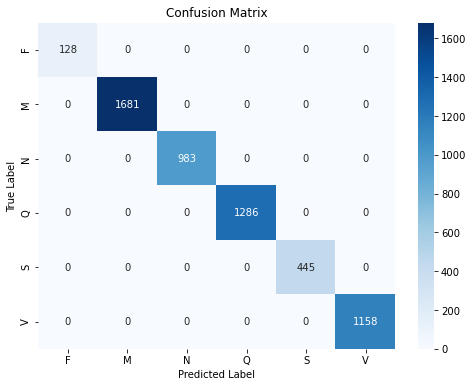

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


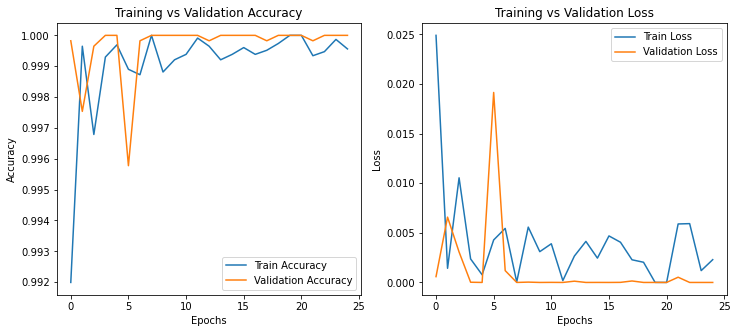

In [51]:
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()


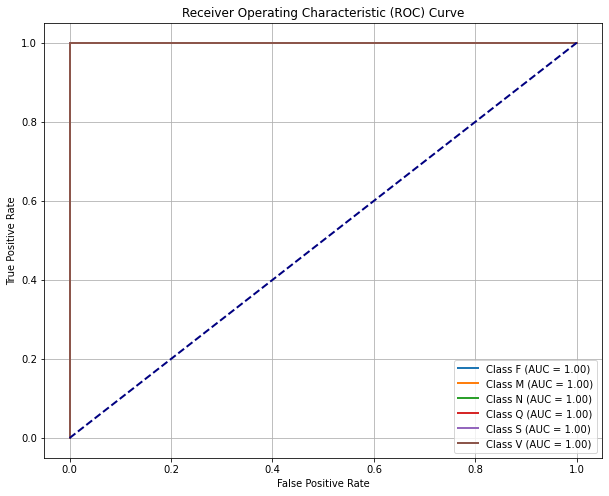

Class: F - AUC: 1.0000
Class: M - AUC: 1.0000
Class: N - AUC: 1.0000
Class: Q - AUC: 1.0000
Class: S - AUC: 1.0000
Class: V - AUC: 1.0000


In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Get true labels and predicted probabilities
y_true = []
y_pred_prob = []

for i in range(len(valid_generator)):
    images, labels = valid_generator[i]
    
    # Predict probabilities for each class
    preds = vit_classifier.predict(images)
    
    # Convert one-hot encoded labels back to class indices
    y_true.extend(np.argmax(labels, axis=1))  # True labels
    y_pred_prob.extend(preds)  # Predicted probabilities (for AUC & ROC)

# Binarize the true labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))  # For multi-class classification

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], np.array(y_pred_prob)[:, i])  # Calculate false positive rate and true positive rate
    roc_auc[i] = auc(fpr[i], tpr[i])  # Calculate AUC for each class
    
    # Plot ROC curve for each class
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot ROC curve for the "no skill" classifier (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)

# Customization
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC for each class
for i in range(NUM_CLASSES):
    print(f"Class: {class_names[i]} - AUC: {roc_auc[i]:.4f}")


In [56]:
# Calculate overall precision, recall, and F1 score (for the entire project)
precision = precision_score(y_true, y_pred, average='macro')  # Overall precision
recall = recall_score(y_true, y_pred, average='macro')  # Overall recall
f1 = f1_score(y_true, y_pred, average='macro')  # Overall F1 score

# Print overall precision, recall, and F1-score
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")
print(f"Overall F1-Score: {f1:.4f}")

Overall Precision: 1.0000
Overall Recall: 1.0000
Overall F1-Score: 1.0000


In [52]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_ecg(img_path, model, class_names):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    
    print(f"Predicted Class: {class_names[class_idx]} with Confidence: {preds[0][class_idx]:.4f}")

# Example usage
predict_ecg("/kaggle/input/ecg-images/ECG-IMAGES/ECG_Image_data/test/F/F104.png", vit_classifier, class_names)


Predicted Class: F with Confidence: 1.0000


In [57]:
import shutil

# Save the model
vit_classifier.save('vit_classifier_model.h5')

# Move model to the working directory for downloading in Kaggle
shutil.move('vit_classifier_model.h5', '/kaggle/working/vit_classifier_model.h5')


'/kaggle/working/vit_classifier_model.h5'

In [59]:
import shutil
from IPython.display import FileLink

link = FileLink('/kaggle/working/vit_classifier_model.h5')
link

/kaggle/working/vit_classifier_model.h5